# MNIST classification: mini-batch gradient descent and adaptive learning rates

This notebook trains a **784 → 64 → 10** fully connected network with a ReLU hidden layer to classify handwritten digits. It compares SGD, default Adam, and an Adam configuration selected by validation loss.

`model.py` contains the network class, the MNIST loader, evaluation, and plotting functions. `parameters.py` contains the architecture, optimization settings, search grid, and file paths. **Open those files to inspect their definitions.** We keep the core forward/backward/update procedure visible below.

Run cells from top to bottom. The included `data/mnist.pkl.gz` is expected to contain training, validation, and test splits. CUDA is used when available; otherwise training runs on CPU.

## 1. Imports and settings

The model and configuration are imported from their respective Python files. Cross-entropy expects **raw logits**, so we only apply softmax to obtain probabilities for display.

In [2]:
from copy import deepcopy
from itertools import product
from pathlib import Path

import pandas as pd
import torch
from torch import nn

from model import (
    OneHiddenLayerNN, load_mnist, make_loaders, evaluate_loss,
    test_predictions, plot_losses, plot_confusion, plot_digit_probabilities_grid,
)
from parameters import (
    SEED, INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, BATCH_SIZE, EPOCHS,
    SGD_LR, ADAM_DEFAULT_LR, ADAM_DEFAULT_BETAS, ADAM_GRID,
    LR_SCHEDULER_FACTOR, LR_SCHEDULER_PATIENCE, EARLY_STOPPING_PATIENCE,
    DATA_PATH, RESULTS_DIR,
)

In [3]:
print(ADAM_GRID)

{'beta1': [0.85, 0.9, 0.95], 'beta2': [0.99, 0.995, 0.999]}


## 2. Load data and construct mini-batches

The supplied images are flattened **28 × 28** grayscale arrays with values in `[0, 1]`. Training batches are shuffled; validation and test batches are not. We recreate the training loader with the same random seed for every run to make comparisons more controlled.

In [4]:
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
results_dir = Path(RESULTS_DIR)
results_dir.mkdir(parents=True, exist_ok=True)

train_data, valid_data, test_data = load_mnist(DATA_PATH)
print(f"Training: {len(train_data):,} | Validation: {len(valid_data):,} | Test: {len(test_data):,}")

def training_loaders():
    return make_loaders(train_data, valid_data, test_data, BATCH_SIZE, SEED,
                        pin_memory=device.type == "cuda")

_, valid_loader, test_loader = training_loaders()

Device: cuda (NVIDIA GeForce RTX 3060 Ti)
Training: 50,000 | Validation: 10,000 | Test: 10,000


## 3. Initialize the network

The network has one hidden layer with ReLU and a ten-logit output. `CrossEntropyLoss` combines log-softmax with the multiclass classification loss. All runs start from the **same weights**; only the optimizer configuration changes.

In [5]:
reference_model = OneHiddenLayerNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
initial_weights = deepcopy(reference_model.state_dict())
print(reference_model)
loss_fn = nn.CrossEntropyLoss()

def fresh_model():
    model = OneHiddenLayerNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
    model.load_state_dict(initial_weights)
    return model.to(device)

OneHiddenLayerNN(
  (hidden): Linear(in_features=784, out_features=64, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
)


## 4. Mini-batch training with an adaptive learning rate

Within each mini-batch we clear gradients, compute logits and loss, backpropagate, and update parameters. After each epoch, **`ReduceLROnPlateau` reduces the learning rate when validation loss stops improving**. Training stops after **10 consecutive epochs without a new lowest validation loss**, up to the maximum specified in `parameters.py`. We restore the weights from the best validation epoch rather than the final epoch.

The scheduler uses a reduction factor of `0.5` and patience of `3` epochs; these, the early-stopping patience, and the maximum number of epochs are defined in `parameters.py`. For a fair comparison, all three optimizer configurations use the same scheduler and stopping rule. Adam's learning rate is therefore *adapted during training*, but its **initial** learning rate is held fixed throughout the grid search.

In [6]:
def train_model(optimizer_name, lr, betas=None):
    model = fresh_model()
    optimizer = (torch.optim.SGD(model.parameters(), lr=lr)
                 if optimizer_name == "SGD" else
                 torch.optim.Adam(model.parameters(), lr=lr, betas=betas))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_SCHEDULER_FACTOR,
        patience=LR_SCHEDULER_PATIENCE,
    )
    train_loader, _, _ = training_loaders()
    history = {"train_loss": [], "valid_loss": [], "lr": []}
    best_loss = float("inf")
    best_weights = None
    best_epoch = 0

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        history["lr"].append(optimizer.param_groups[0]["lr"])
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device, non_blocking=device.type == "cuda")
            y_batch = y_batch.to(device, non_blocking=device.type == "cuda")
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)

        train_loss = total_loss / len(train_data)
        valid_loss = evaluate_loss(model, valid_loader, loss_fn, device)
        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_epoch = epoch + 1
            best_weights = deepcopy(model.state_dict())
        scheduler.step(valid_loss)
        if epoch + 1 - best_epoch >= EARLY_STOPPING_PATIENCE:
            break

    model.load_state_dict(best_weights)
    return model, history, best_loss, best_epoch

## 5. Grid search: Adam moment coefficients

We vary Adam's **first- and second-moment coefficients** \(\beta_1\) and \(\beta_2\), holding its initial learning rate at `0.001`. The scheduler subsequently adjusts the learning rate according to validation loss. The selected configuration minimizes the **best observed validation loss**, and different trials may stop at different epochs. The test set plays no role in selection.

In [7]:
search_rows = []
adam_histories = {}
for beta1, beta2 in product(ADAM_GRID["beta1"], ADAM_GRID["beta2"]):
    label = f"β1={beta1:g}, β2={beta2:g}"
    _, history, best_loss, best_epoch = train_model(
        "Adam", ADAM_DEFAULT_LR, betas=(beta1, beta2)
    )
    adam_histories[label] = history
    search_rows.append({"beta1": beta1, "beta2": beta2, "valid_loss": best_loss,
                        "best_epoch": best_epoch, "epochs_run": len(history["valid_loss"])})

search_results = pd.DataFrame(search_rows).sort_values("valid_loss").reset_index(drop=True)
best_betas = (float(search_results.loc[0, "beta1"]), float(search_results.loc[0, "beta2"]))
print(search_results.to_string(index=False, float_format="%.4f"))
print(f"Selected Adam betas: {best_betas}")
search_results.to_csv(results_dir / "adam_grid.csv", index=False)

 beta1  beta2  valid_loss  best_epoch  epochs_run
0.8500 0.9900      0.0862          15          25
0.8500 0.9950      0.0877          15          25
0.8500 0.9990      0.0882          22          32
0.9000 0.9900      0.0885          16          26
0.9000 0.9990      0.0887          18          28
0.9000 0.9950      0.0889          16          26
0.9500 0.9900      0.0892          17          27
0.9500 0.9990      0.0899          24          34
0.9500 0.9950      0.0905          17          27
Selected Adam betas: (0.85, 0.99)


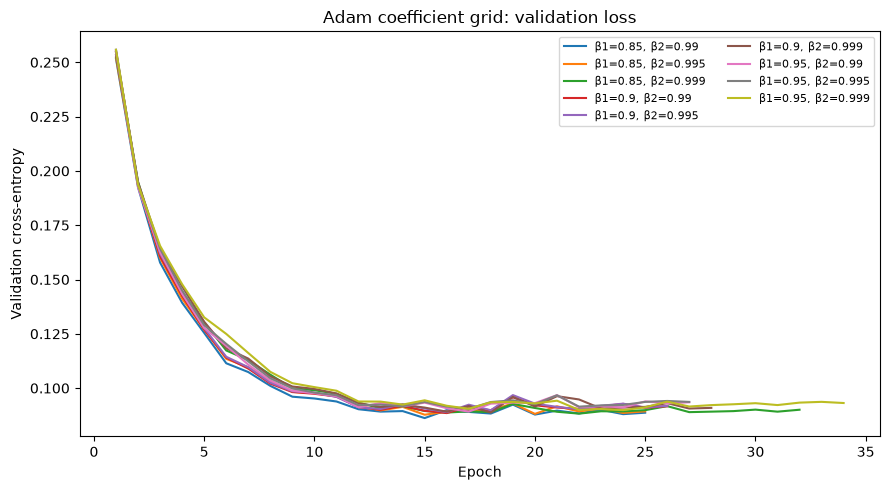

In [8]:
plot_losses(adam_histories, results_dir / "adam_grid_loss.png",
            "Adam coefficient grid: validation loss")

## 6. Compare SGD, default Adam, and tuned Adam

We re-train each optimizer from identical initial weights and use the same minibatch ordering, scheduler, and early-stopping rule. **SGD uses no momentum**; default Adam uses PyTorch's standard initial learning rate and moment coefficients; tuned Adam uses the selected moment coefficients. Only Adam is tuned, so the comparison does not represent equal hyperparameter-search effort.

In [9]:
experiments = {
    "SGD": ("SGD", SGD_LR, None),
    "Default Adam": ("Adam", ADAM_DEFAULT_LR, ADAM_DEFAULT_BETAS),
    "Tuned Adam": ("Adam", ADAM_DEFAULT_LR, best_betas),
}
models = {}
histories = {}
for name, (optimizer_name, lr, betas) in experiments.items():
    model, history, best_loss, best_epoch = train_model(optimizer_name, lr, betas)
    models[name] = model
    histories[name] = history
    print(f"{name}: best validation loss={best_loss:.4f} at epoch {best_epoch} "
          f"({len(history['valid_loss'])} epochs run)")

SGD: best validation loss=0.1355 at epoch 100 (100 epochs run)
Default Adam: best validation loss=0.0887 at epoch 18 (28 epochs run)
Tuned Adam: best validation loss=0.0862 at epoch 15 (25 epochs run)


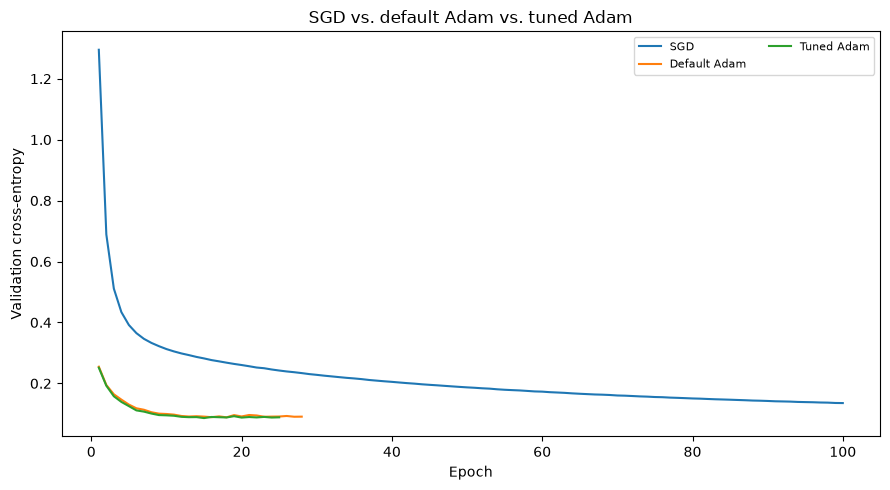

In [10]:
plot_losses(histories, results_dir / "optimizer_comparison_loss.png",
            "SGD vs. default Adam vs. tuned Adam")

## 7. Held-out classification

We report test accuracy for all three trained configurations. The confusion matrix and digit probability figure use the **validation-selected tuned Adam model**, with its best-epoch weights restored. Softmax is only used here to interpret the ten logits.

   optimizer test_accuracy
         SGD         0.961
Default Adam         0.975
  Tuned Adam         0.975


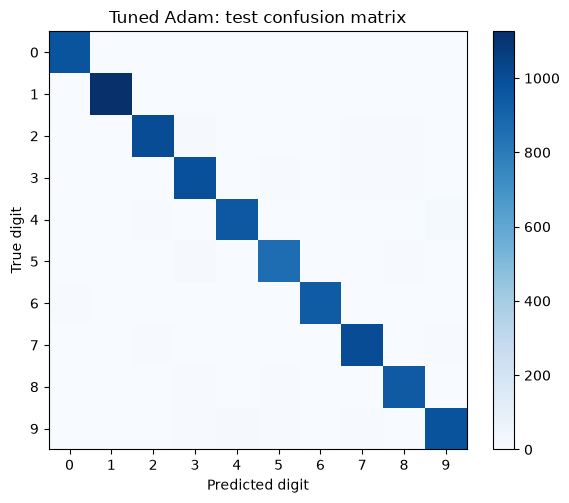

In [11]:
summary = []
for name, model in models.items():
    accuracy, matrix = test_predictions(model, test_loader, device, OUTPUT_DIM)
    summary.append({"optimizer": name, "test_accuracy": accuracy})
    if name == "Tuned Adam":
        tuned_confusion = matrix
accuracy_table = pd.DataFrame(summary)
print(accuracy_table.to_string(index=False, formatters={"test_accuracy": "{:.3f}".format}))
accuracy_table.to_csv(results_dir / "test_accuracy.csv", index=False)
plot_confusion(tuned_confusion, results_dir / "confusion_matrix.png")

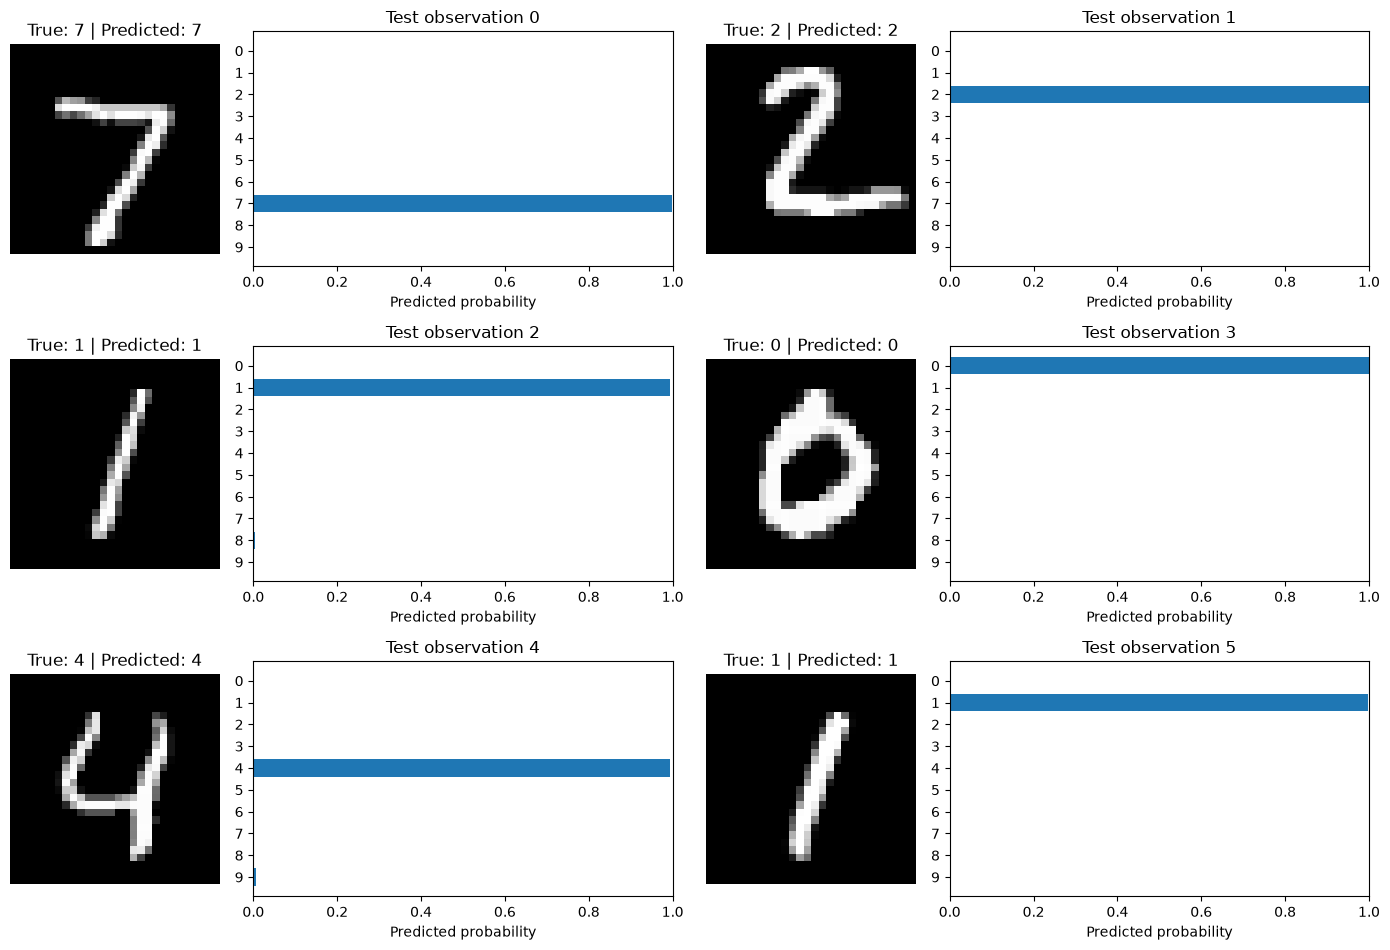

In [12]:
plot_digit_probabilities_grid(
    models["Tuned Adam"], test_data, indices=[0, 1, 2, 3, 4, 5],
    device=device, n_classes=OUTPUT_DIM,
    filename=results_dir / "digit_probabilities.png",
)
torch.save(models["Tuned Adam"].state_dict(), results_dir / "tuned_adam.pt")


## 8. Saved results

Running the notebook creates `results/` (excluded by `.gitignore`) and writes the Adam grid table, two validation-loss plots, test accuracy, confusion matrix, grid of digit-probability examples, and tuned Adam model weights. These outputs must be regenerated by running the notebook; they are not included in the repository.

**Note:** The learning-rate scheduler and early stopping are both based on validation loss. Because training may stop early, curves can have different lengths. CUDA and CPU runs may differ slightly due to hardware-dependent numerical behavior.